----

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


## Sección 1 - Cargar y explorar el dataset

In [2]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
import numpy as np

### Cargar Dataset

In [3]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [4]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

In [5]:
# Corregir el tipo de dato
df["satisfaccion"] = df["satisfaccion"].round().astype(int)

In [6]:
df["edad"] = df["edad"].round().astype(int)

In [7]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  int64  
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [9]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.612400,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.741577,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.000000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,4.000000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.000000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


#### Explorar variables binarias

In [12]:
# Verificar que cada columna tenga únicamente dos valores posibles
df["miembro_premium"].unique()
df["abandono"].unique()

array([0, 1])

In [13]:
print("Valores únicos en miembro_premium:")
print(df['miembro_premium'].unique())
print(f"Cantidad de valores únicos: {df['miembro_premium'].nunique()}")

print("\nValores únicos en abandono:")
print(df['abandono'].unique())
print(f"Cantidad de valores únicos: {df['abandono'].nunique()}")

Valores únicos en miembro_premium:
[0 1]
Cantidad de valores únicos: 2

Valores únicos en abandono:
[0 1]
Cantidad de valores únicos: 2


In [15]:
print("=== MIEMBRO PREMIUM ===")
prop_premium = df['miembro_premium'].value_counts(normalize=True)
print("Proporciones:")
print(prop_premium)
print(f"Porcentaje de miembros premium: {prop_premium[1]*100:.1f}%")
print(f"Porcentaje de miembros no premium: {prop_premium[0]*100:.1f}%")

print("\n=== ABANDONO ===")
prop_abandono = df['abandono'].value_counts(normalize=True)
print("Proporciones:")
print(prop_abandono)
print(f"Porcentaje de clientes que abandonaron: {prop_abandono[1]*100:.1f}%")
print(f"Porcentaje de clientes que no abandonaron: {prop_abandono[0]*100:.1f}%")

=== MIEMBRO PREMIUM ===
Proporciones:
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64
Porcentaje de miembros premium: 13.9%
Porcentaje de miembros no premium: 86.1%

=== ABANDONO ===
Proporciones:
0    0.849267
1    0.150733
Name: abandono, dtype: float64
Porcentaje de clientes que abandonaron: 15.1%
Porcentaje de clientes que no abandonaron: 84.9%


#### Explorar variables categóricas

In [16]:
# Verificar el número de valores únicos por variable categórica
print("tipo_dispositivo:", df["tipo_dispositivo"].nunique())
print("region:", df["region"].nunique())
print("id_cliente", df["id_cliente"].nunique())

tipo_dispositivo: 3
region: 4
id_cliente 15000


In [21]:
# Explorar variables categóricas y cómo se distribuyen
print("Valores únicos en tipo_dispositivo:", df["tipo_dispositivo"].value_counts(normalize=True))
print()

print("Valores únicos en region:", df["region"].value_counts(normalize=True))
print()
print("Valores únicos en id_cliente", df["id_cliente"].unique())

Valores únicos en tipo_dispositivo: móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

Valores únicos en region: norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64

Valores únicos en id_cliente ['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

In [22]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
corr

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.003805,0.004605,-0.011500,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,-0.000625,-0.005598,0.005870,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,0.000957,-0.012657,-0.008943,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,0.003042,0.003431,0.008291,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.012203,0.002721,-0.004586,0.197483
satisfaccion,-0.003805,-0.000625,0.000957,0.003042,-0.012203,1.000000,0.024070,-0.021769,0.057420
miembro_premium,0.004605,-0.005598,-0.012657,0.003431,0.002721,0.024070,1.000000,-0.120488,0.093099
abandono,-0.011500,0.005870,-0.008943,0.008291,-0.004586,-0.021769,-0.120488,1.000000,-0.002824
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.057420,0.093099,-0.002824,1.000000


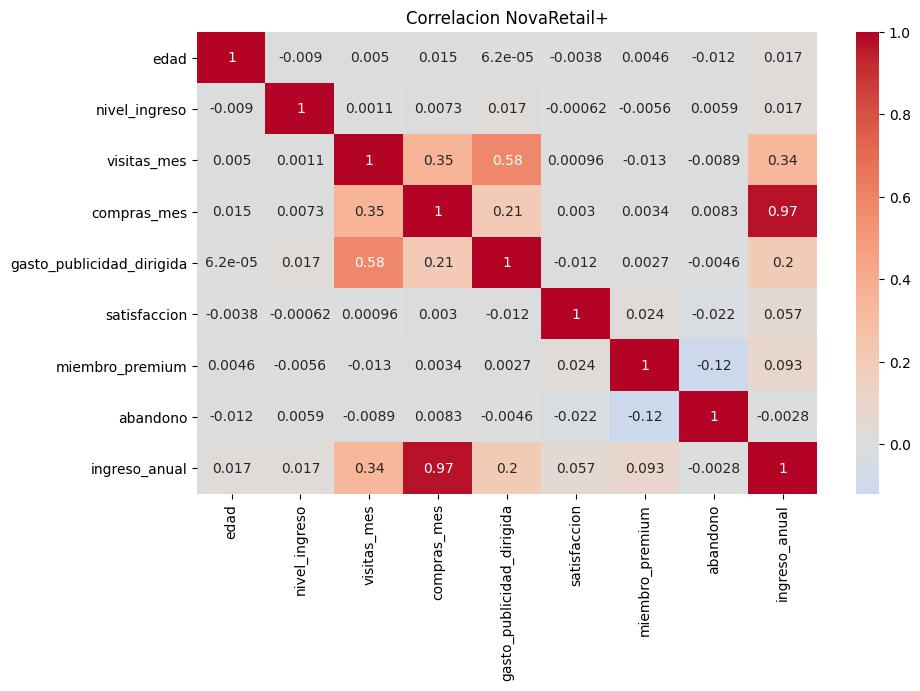

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlacion NovaRetail+")
plt.show()

✍️ **Comentario**: 

Observaciones generales (Heatmap)  
- Se observa que las visitas al mes tienen una relación ligera con el gasto de publicidad dirigido, al igual que compras al mes con visitas al mes


Observaciones respecto a `ingreso_anual`  
- Presenta una mayor correlación fuerte con las compras mensuales, correlación media con las visitas al mes
- El abandono tiene una correlación negativa con el ingreso anual


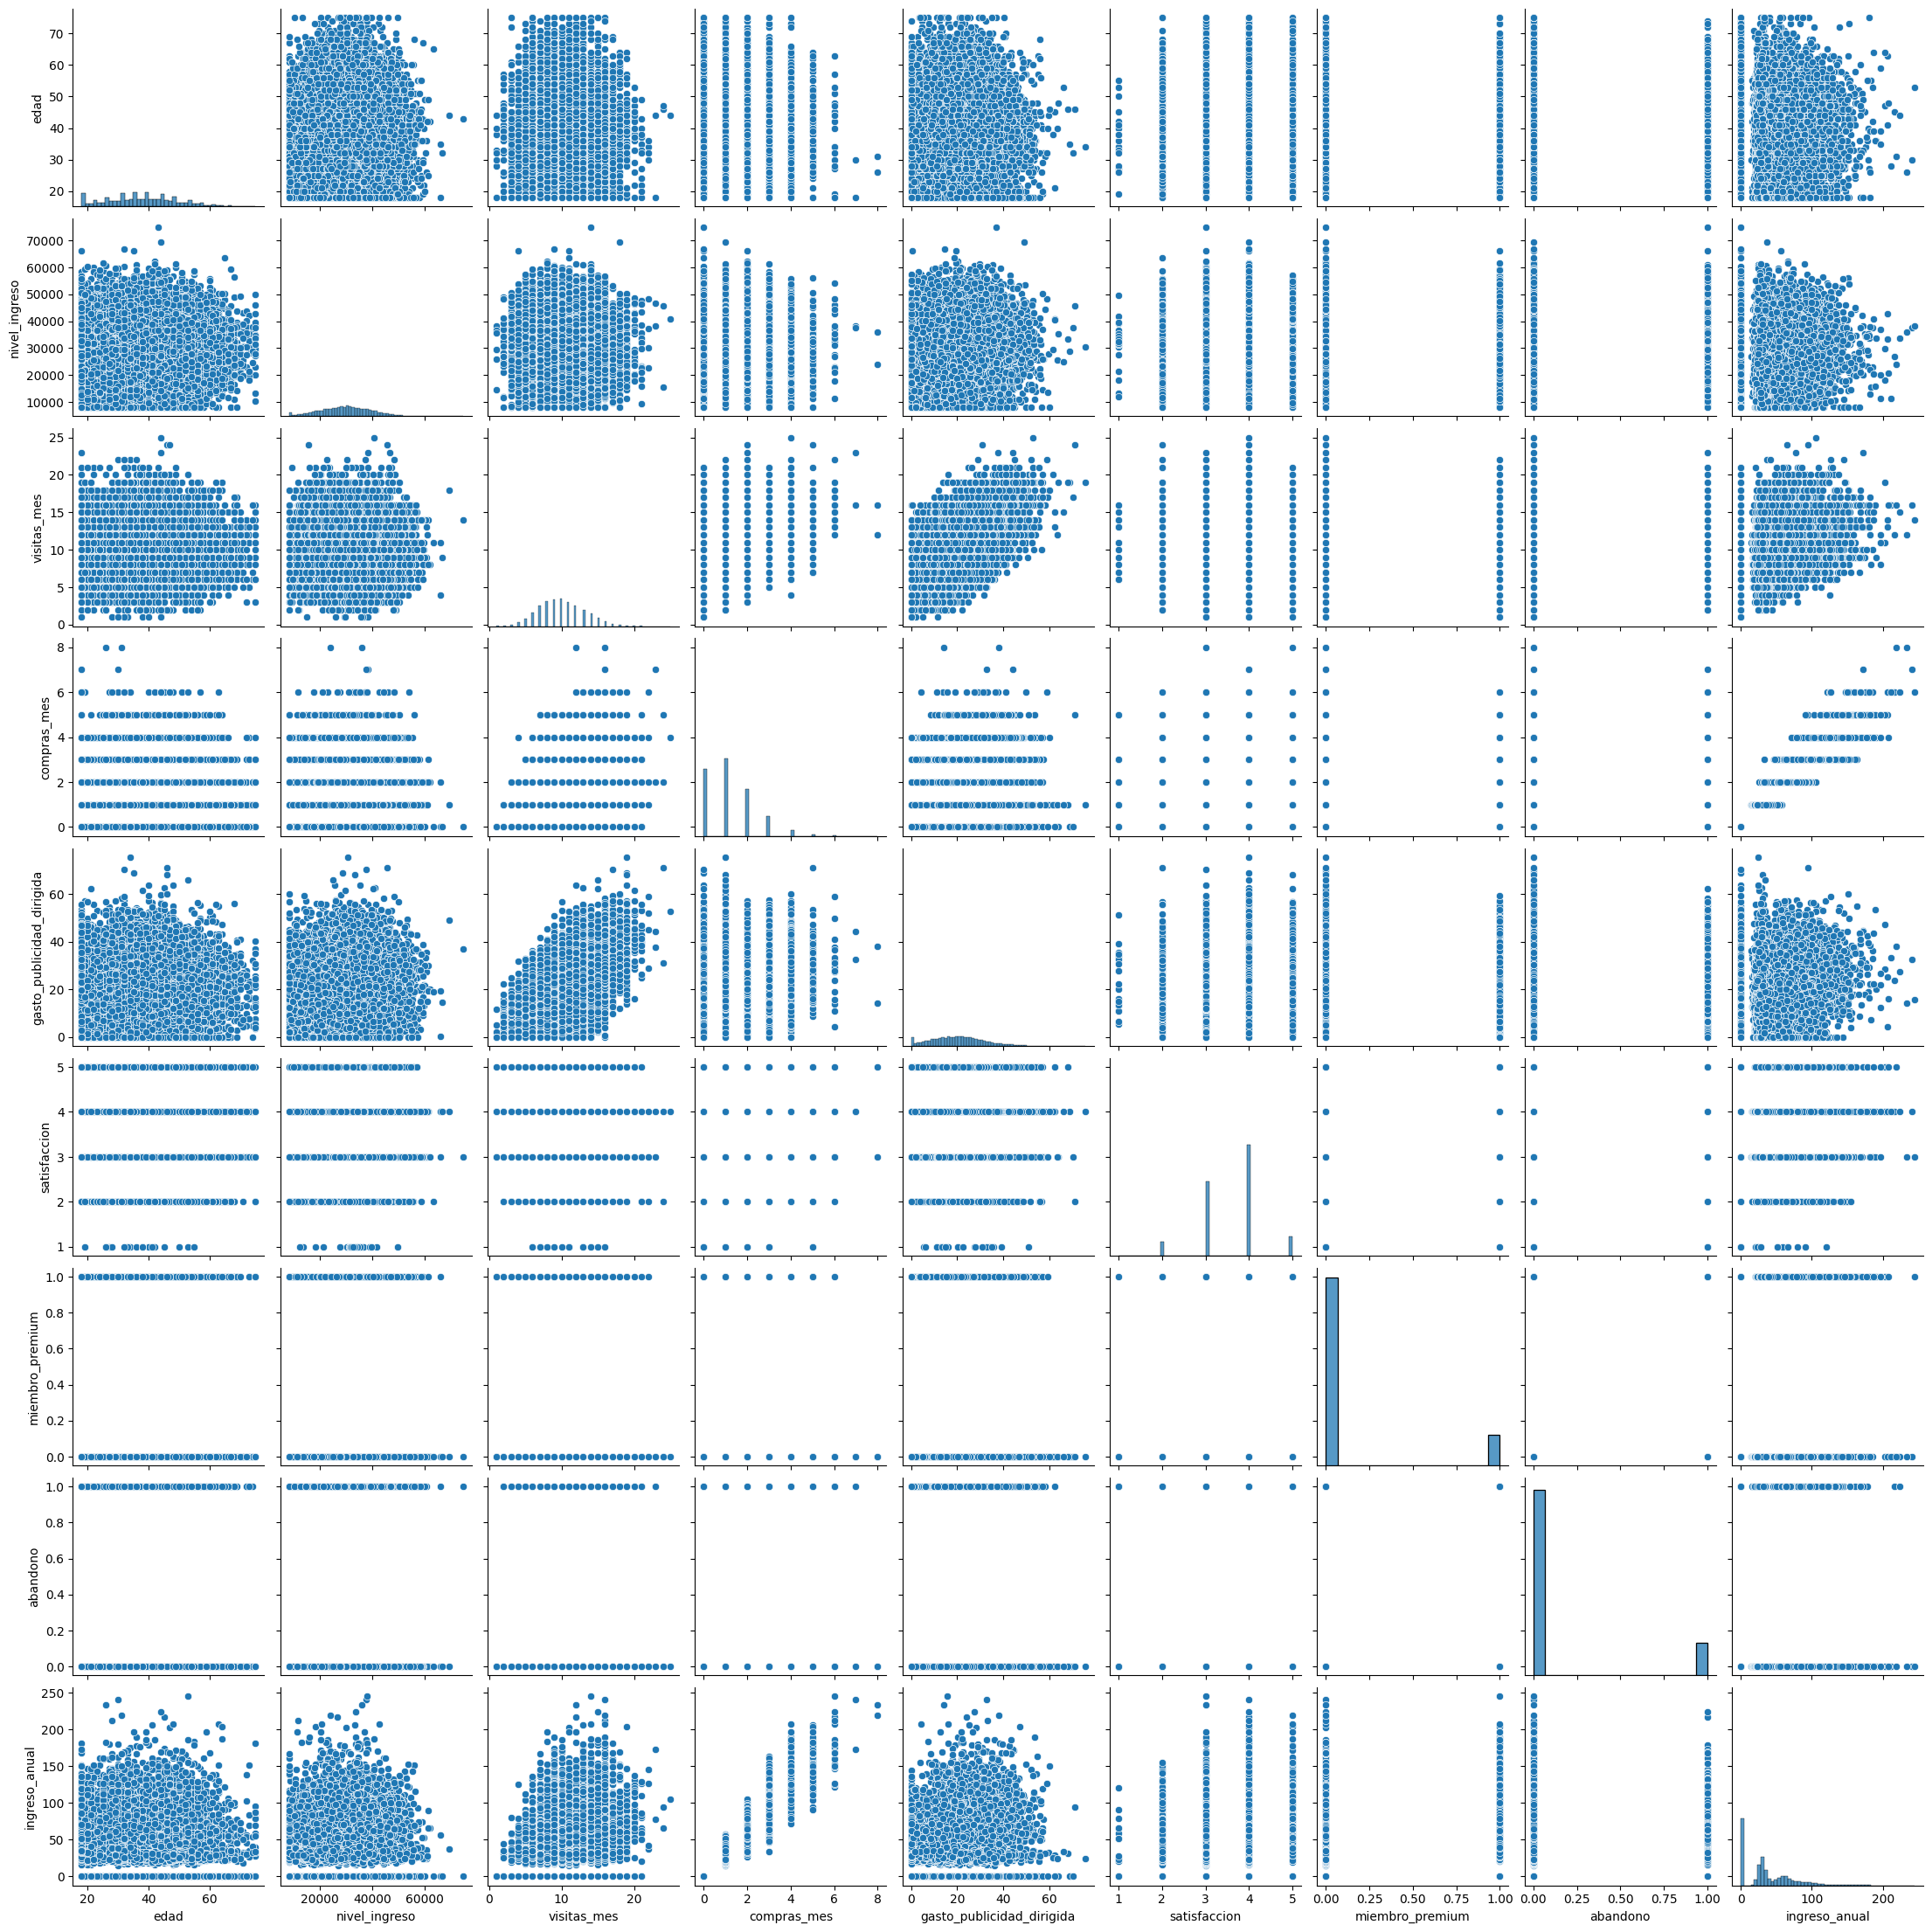

In [50]:
sns.pairplot(df)

### Scatterplot para pares clave

<AxesSubplot:xlabel='ingreso_anual', ylabel='compras_mes'>

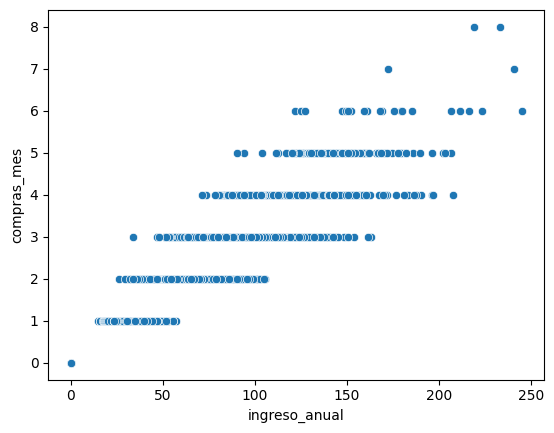

In [48]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x="ingreso_anual", y="compras_mes")

<AxesSubplot:xlabel='ingreso_anual', ylabel='visitas_mes'>

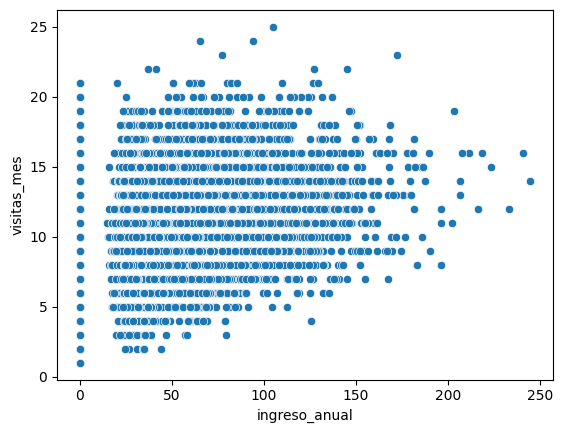

In [49]:
sns.scatterplot(data=df,x="ingreso_anual", y="visitas_mes")

✍️ **Comentario**:

**ingreso_anual vs compras_mes**
- Dirección positiva, dispersión baja (correlación fuerte), hay presencia de outliers y nula colinealidad

**ingreso_anual vs visitas_mes**
- Dirección positiva, dispersión media, hay presencia de outliers y  nula colinealidad

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [25]:
# Calcular correlación entre variables relevantes
print(df['ingreso_anual'].corr(df['compras_mes'], method='pearson'))
print(df['ingreso_anual'].corr(df['compras_mes'], method='spearman'))

0.9671485435708566
0.9674824920326731


In [55]:
# Calcular correlación entre variables relevantes
print(df['ingreso_anual'].corr(df['visitas_mes'], method='pearson'))
print(df['ingreso_anual'].corr(df['visitas_mes'], method='spearman'))

0.33714664324987453
0.3209536973769648


### Punto-biserial

In [58]:
# Calcular correlación entre variables relevantes
df["ingreso_anual"] = df["miembro_premium"].replace({"Yes": 1, "No": 0 })

# Calcular la correlación punto-biserial
pointbiserialr( df["ingreso_anual"], df["miembro_premium"] )

SignificanceResult(statistic=0.9999999999999994, pvalue=0.0)

In [59]:
# Calcular correlación entre variables relevantes
df["ingreso_anual"] = df["abandono"].replace({"Yes": 1, "No": 0 })

# Calcular la correlación punto-biserial
pointbiserialr( df["ingreso_anual"], df["abandono"] )

SignificanceResult(statistic=1.0, pvalue=0.0)

✍️ **Comentario**: 

Observaciones Punto-biserial
 
**ingreso_anual vs miembro_premium**
- Relación fuerte

**ingreso_anual vs abandono**
- Relación furte

### V de Cramér

In [71]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df["region"], df["tipo_dispositivo"])

tabla

tipo_dispositivo,escritorio,móvil,tablet
region,,,
este,766,2003,300
norte,1125,2843,427
oeste,935,2489,386
sur,894,2483,349


In [79]:
# Aplicar V de Cramér en variables relevantes
tabla = pd.crosstab(df["region"], df["tipo_dispositivo"])
chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
cramers_v

0.012378338407739397

✍️ **Comentario**: 

Observaciones V de Cramér
La relación entre región y tipo de dispositivo es débil, la región no influye para el tipo de dispositivo que utiliza el usuario

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — La compra mensual aumenta el ingreso anual

**Evidencia visual:**   
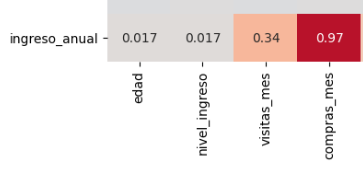 

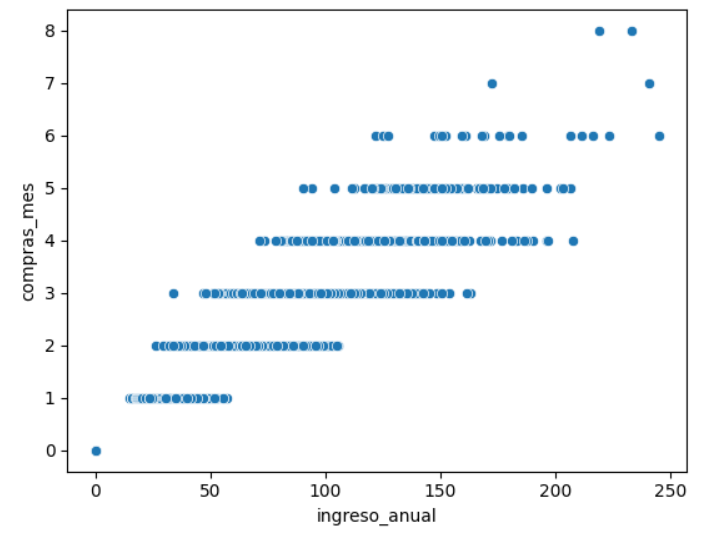

**Evidencia numérica:** 

El nivel de correlación es: 0.967

**Interpretación**  

La cantidad de compras realizadas en el mes elevan el ingreso anual

**No podemos afirmar**  

Que los usuarios con membresia premiun compren más

**Implicación de negocio**  

Habría que analizar el comportamiento de ambos usuarios, con y sin membresía, respecto a las compras para valorar si se está destinando el gasto publicitario de forma eficiente

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

En realidad no se puede interpretar que haya una implicancia, sino que los usuarios con mayor número de compras tienden a generar más ingresos para la compañía.



</div>

### Hallazgo 2 —  La región norte registra más usuarios en los diferentes dispositivos que la demás regiones

**Evidencia visual:**   

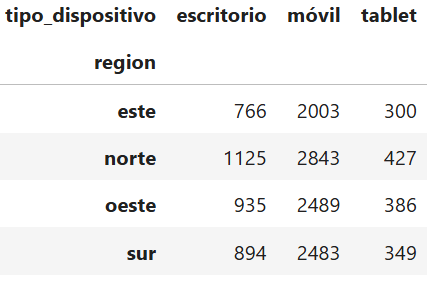

**Evidencia numérica:** 

Cramers_v = 0.012378338407739397

**Interpretación**  

La región norte tiene más usuarios utilizando los 3 dispositivos principales

**No podemos afirmar**  

Que el registro de ellos se relacione con más compras mensuales, más visitas mensuales y por lo tanto más ingresos anuales

**Implicación de negocio**  

Se sugiere analizar usuario contra región, compras por región e ingreso anual por región


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien con la interpretación. De forma adicional, podemos decir que los usuarios con mayor cantidad de visitas tienden a generar más ingresos.



</div>

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Falta de exploración de segmentos

### **Próximos pasos** 

Probar segmentación adicional

- Miembros premium y no premium  
- Compras por región
- Análisis por cohortes
- Diseño de experimentos para cuantificar la retención de clientes